Covers the topics of:
- Backpropagation

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

### What `np.arange(-5, 5, 0.25)` does

`np.arange(-5, 5, 0.25)` creates a NumPy array of numbers:

- starting at `-5`
- increasing by `0.25`
- stopping **before** `5`

So it produces values like:

```python
[-5.00, -4.75, -4.50, -4.25, ..., 4.50, 4.75]

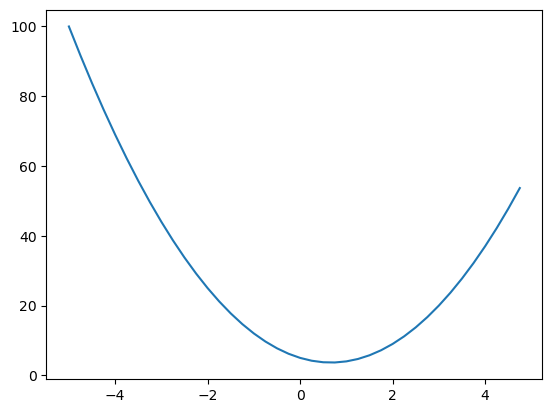

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
# back to school
# understanding the concept of slope in calculus.

h = 0.000001
x = 3
(f(x + h) - f(x))/h

14.000003002223593

In [6]:
h = 0.0000000000000001
x = 3
(f(x + h) - f(x))/h

0.0

PROBLEM: we encountered out of scope problem with the value being `0`. Lets say float has a finite size, which means its MSB will have a limit. 
- So neural networks with FP4 might have to compromise with the value of weights compared with FP16. 
- We can some to that later. But for example would be DeepSeek R1

In [7]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


### Significance of `__add__` in this code

`__add__` is a special Python method used for the `+` operator.

In this code:

```python
c = a + b

Why you cannot replace __add__ with any other keyword
You cannot use just any name because __add__ is a special reserved method name in Python's data model.

Python looks specifically for:

__add__ for +
__sub__ for -
__mul__ for *
__truediv__ for /
If you rename it to something else, 

In [15]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e' 
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
# e._prev

In [16]:
# e._prev = {Value(data=-3.0), Value(data=2.0)} ------- but how?
# in this line: 
# e = a*b; e.label = 'e'
# a+b calls the Value.__mul__() method -> REASON -> a and b both are objects of class 'Value'
# so a.__mul__(b) is called, therefore:-
# self <- a
# other <- b
# inside the __mul__ it calls:-
# out = Value(self.data * other.data, (self, other), '*') ----- the constructor is called 
# out = Value(2.0 * (-3.0), (a, b), '*')
# NOW: _children = (a, b) ; _op = '*' ; label = '' ----- FROM THE CONSTRUCTOR
# THEN: self._prev = set((a, b))
# i.e. e._prev = {a, b}
# and now when we are trying to display `e` then the output is `{Value(data=-3.0), Value(data=2.0)}`
# REASON: 
# `__repr__` is called when Python needs the **string representation** of an object, usually for debugging or display.
# In your class:
# def __repr__(self):
#     return f"Value(data={self.data})"

Graph Visualization (calling the graphviz api)

In [17]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

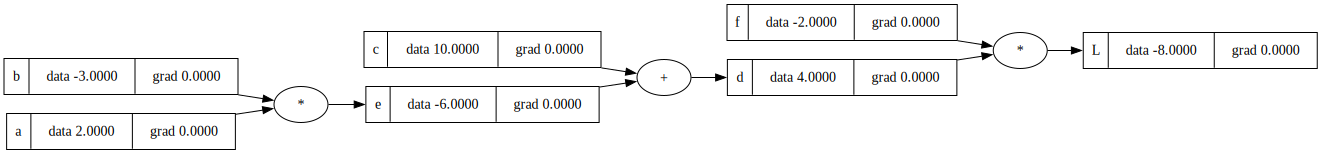

In [18]:
draw_dot(L)

In [ ]:
# EXAMPLE: 
# here the grad of `f` is the derivative of the output which in this case is `L` w.r.t. `f`
